In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")


In [3]:
from sklearn.datasets import make_moons
from mlxtend.plotting import plot_decision_regions

import tensorflow as tf
from tensorflow import keras 
from keras.models import Sequential
from keras.layers import Dense , Dropout 
from keras.optimizers import Adam



In [15]:
X, y = make_moons(1000, noise=0.25,random_state=2)

In [17]:
X.shape

(1000, 2)

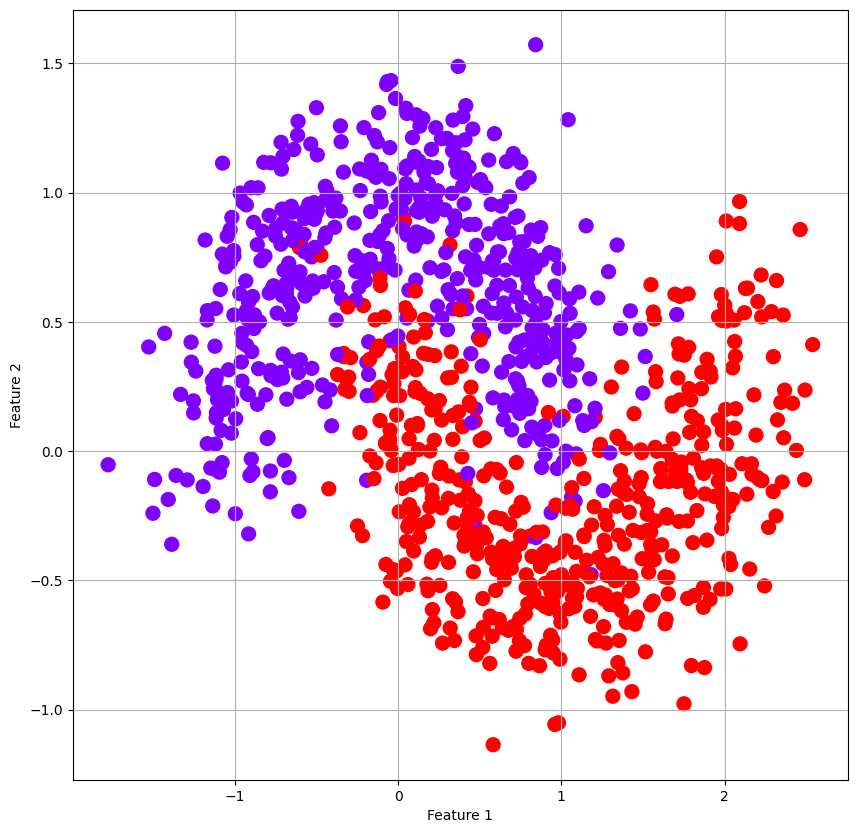

In [16]:
plt.figure(figsize = (10 , 10))
plt.scatter(X[: , 0] , X[: , 1] , c = y , s = 100 , cmap = "rainbow")
plt.grid(True)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [18]:
model1 = Sequential()

model1.add(Dense(128 , activation = 'relu' , input_dim = 2))
model1.add(Dense(256 , activation = 'relu'))
model1.add(Dense(1 , activation = 'sigmoid' ))

model1.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,665 (131.50 KB)

 Trainable params: 33,665 (131.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model1.compile(loss = 'binary_crossentropy' , optimizer = Adam(learning_rate = 0.01) , metrics = ['accuracy'])

from keras.callbacks import ModelCheckpoint
callback = ModelCheckpoint("best_model_without_reg.h5" , monitor = 'validation_loss' , save_best_only = True  , verbose = 1) 
history1 = model1.fit(X ,y, epochs = 200 , batch_size = 32 , validation_split = 0.2 , verbose = 1 , callbacks = [callback])





Epoch 1/200
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9405 - loss: 0.1471

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9420 - loss: 0.1441 - val_accuracy: 0.9200 - val_loss: 0.4033
Epoch 2/200
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9631 - loss: 0.0936 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9620 - loss: 0.0969 - val_accuracy: 0.9200 - val_loss: 0.3824
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9465 - loss: 0.1222 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9470 - loss: 0.1217 - val_accuracy: 0.9150 - val_loss: 0.4394
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9691 - loss: 0.0942 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9688 - loss: 0.0946 - val_accuracy: 0.9300 - val_loss: 0.3556
Epoch 5/200
 1/25 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0387

...

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9588 - loss: 0.0865 - val_accuracy: 0.9200 - val_loss: 0.7304
Epoch 197/200
17/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9562 - loss: 0.1084 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9584 - loss: 0.1031 - val_accuracy: 0.9250 - val_loss: 0.6958
Epoch 198/200
18/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9751 - loss: 0.0754 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9718 - loss: 0.0815 - val_accuracy: 0.9250 - val_loss: 0.6899
Epoch 199/200
17/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9720 - loss: 0.1064 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9696 - loss: 0.1043 - val_accuracy: 0.9300 - val_loss: 0.6265
Epoch 200/200
13/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9553 - loss: 0.0890 

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9575 - loss: 0.0854 - val_accuracy: 0.9200 - val_loss: 0.6670


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step


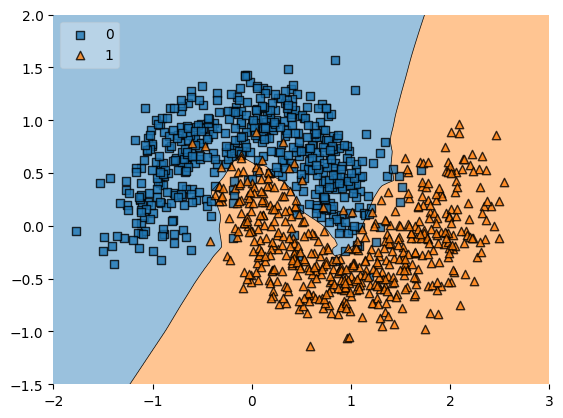

In [21]:
plot_decision_regions(X, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

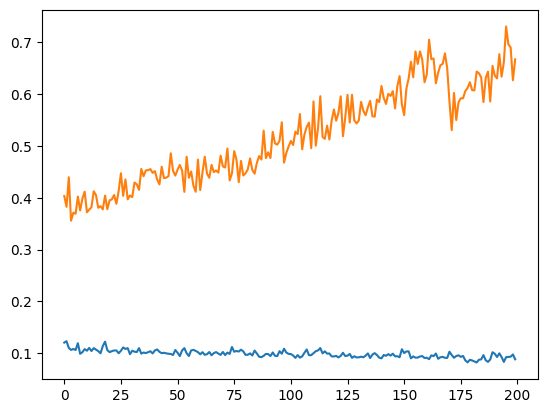

In [22]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

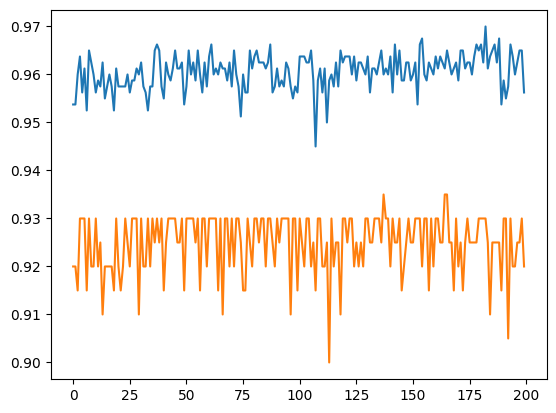

In [23]:
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])

This clearly shows that the model is overfitting and the loss is 
increasing with the each epochs 


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

import tensorflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam

In [28]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])

history2 = model2.fit(X, y, epochs=2000, validation_split = 0.2,verbose=0)

Below is a **clear, practical guide** to **which regularization to use, when to use it, and why**—with intuition, symptoms, and examples you can directly apply to your Keras model.

---

# 🧠 Regularization 

## 1️⃣ **L1 Regularization (Lasso)**

### 🔍 What it does

* Pushes **many weights exactly to zero**
* Performs **automatic feature selection**

### ✅ Use L1 when:

* You want to **identify important features**
* Your input features may be **irrelevant or redundant**
* You want a **sparse model**
* Model interpretability matters

### ❌ Avoid L1 when:

* You have **deep networks**
* You need **smooth optimization**
* All features are important

### 📌 Symptoms it fixes

| Problem                       | Effect          |
| ----------------------------- | --------------- |
| Too many useless features     | Eliminates them |
| Overfitting with noisy inputs | Reduces noise   |

### 🧪 Example

```python
Dense(128, activation="relu",
      kernel_regularizer=tf.keras.regularizers.l1(0.001))
```

---

## 2️⃣ **L2 Regularization (Ridge)** ⭐ MOST COMMON

### 🔍 What it does

* Penalizes **large weights**
* Keeps all features but makes weights smaller
* Stabilizes training

### ✅ Use L2 when:

* You have **overfitting**
* You want **generalization**
* You don’t know which features matter
* Training is unstable

### ❌ Avoid L2 when:

* You explicitly want **feature selection**

### 📌 Symptoms it fixes

| Problem             | Effect   |
| ------------------- | -------- |
| Overfitting         | Reduces  |
| Large weight spikes | Smooths  |
| High variance       | Controls |

### 🧪 Example

```python
Dense(128, activation="relu",
      kernel_regularizer=tf.keras.regularizers.l2(0.001))
```

📌 **Default choice if unsure**

---

## 3️⃣ **L1 + L2 (Elastic Net)**

### 🔍 What it does

* L1 → sparsity
* L2 → stability

### ✅ Use Elastic Net when:

* You want **some feature selection**
* Features are **correlated**
* Pure L1 is too unstable

### ❌ Avoid when:

* Model is already simple
* Dataset is very small

### 🧪 Example

```python
Dense(128, activation="relu",
      kernel_regularizer=tf.keras.regularizers.l1_l2(
          l1=0.001,
          l2=0.001
      ))
```

---

## 4️⃣ **Dropout (not weight regularization, but critical)**

### 🔍 What it does

* Randomly disables neurons
* Forces redundancy and robustness

### ✅ Use Dropout when:

* Model is **deep**
* Dataset is **small**
* You see heavy overfitting

### ❌ Avoid Dropout when:

* Model is very shallow
* Dataset is huge
* Using batch normalization heavily

### 📌 Typical values

| Layer type | Dropout   |
| ---------- | --------- |
| Dense      | 0.2 – 0.5 |
| Input      | 0.1 – 0.2 |

### 🧪 Example

```python
Dense(128, activation="relu")
Dropout(0.3)
```

---

## 5️⃣ **Activity Regularization (Advanced / Rare)**

### 🔍 What it does

* Penalizes **large activations**
* Encourages sparse neuron firing

### ✅ Use when:

* You want **biological sparsity**
* Using **autoencoders**
* Activations explode

### ❌ Avoid for:

* Standard classification tasks

```python
activity_regularizer=tf.keras.regularizers.l1(0.001)
```

---

## 6️⃣ **Bias Regularization (Almost Never)**

### 🔍 What it does

* Penalizes bias terms

### ✅ Use when:

* Strong theoretical reason
* Research experiments

### ❌ Default:

❌ **Don’t use**

---

# 🏆 Best Practices (What professionals do)

### ✔ Default setup (90% of cases)

```python
L2(1e-3) + Dropout(0.2–0.4)
```

### ✔ Tabular data

```python
L1 or Elastic Net
```

### ✔ Deep neural networks

```python
L2 + Dropout
```

### ✔ Small datasets

```python
Strong L2 + Dropout
```

### ✔ Feature selection needed

```python
L1 or Elastic Net
```

---

# 🧪 Regularization Strength Guide

| Value | Effect             |
| ----- | ------------------ |
| 1e-5  | Almost none        |
| 1e-4  | Light              |
| 1e-3  | Moderate           |
| 1e-2  | Strong             |
| 1e-1  | Usually too strong |

---

# 🎯 Your model (recommended choice)

Since you have:

* Small input (`input_dim=2`)
* Dense layers
* Binary classification

👉 **Use L2, not L1**

```python
Dense(128, activation="relu",
      kernel_regularizer=tf.keras.regularizers.l2(0.001))
```

---

## 📌 One-sentence summary

> **L2 for generalization, L1 for feature selection, Elastic Net for both, Dropout for deep overfitting.**

If you want, I can:

* diagnose overfitting from your loss curves
* tune exact regularization values
* compare L1 vs L2 visually on your model


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step


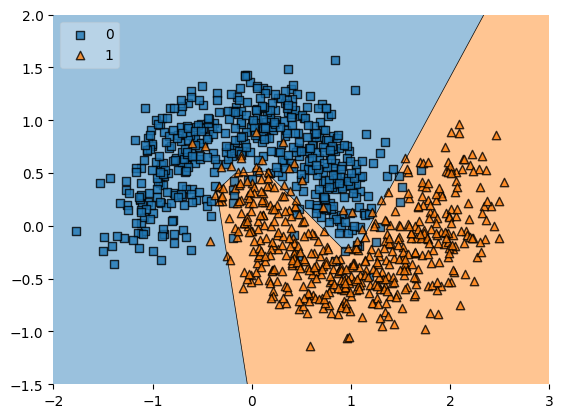

In [30]:
plot_decision_regions(X, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

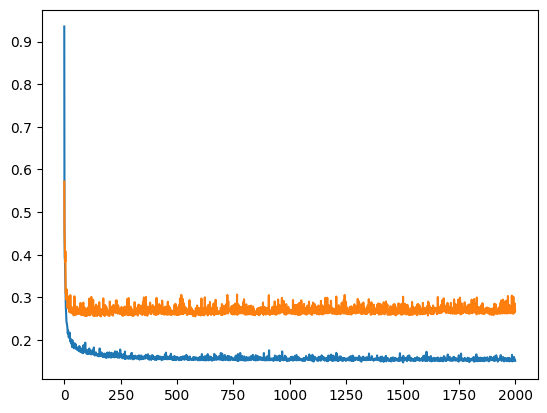

In [31]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

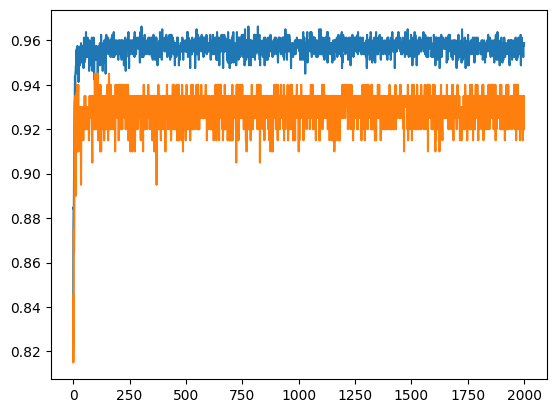

In [32]:
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])

In [33]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)

visualize the effect of regualarization on the training of the model 


<Axes: >

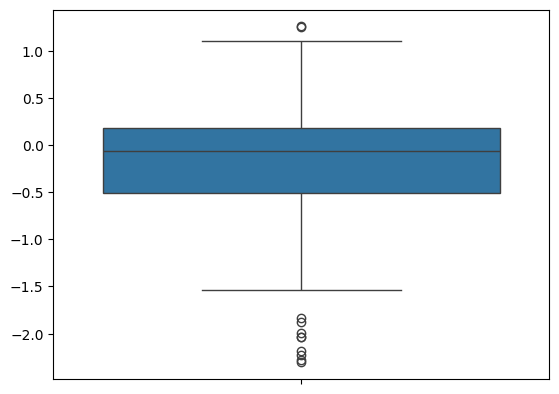

In [34]:
sns.boxplot(model1_weight_layer1)

<Axes: >

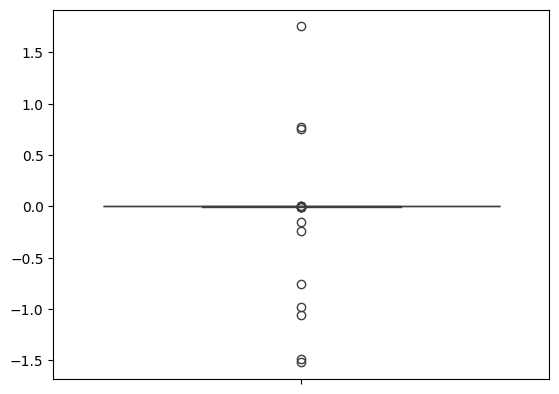

In [35]:
sns.boxplot(model2_weight_layer1)

In [36]:
model1_weight_layer1.min()

np.float32(-2.3049788)

In [37]:
model2_weight_layer1.min()

np.float32(-1.5190444)

<Axes: ylabel='Density'>

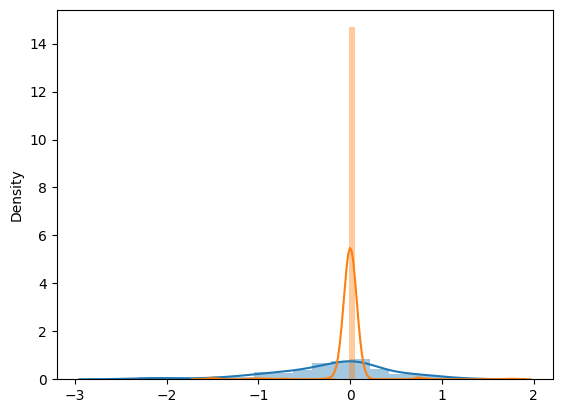

In [38]:
sns.distplot(model1_weight_layer1)
sns.distplot(model2_weight_layer1)

In [39]:
model1.get_weights()[0].reshape(256)

array([-8.35281491e-01,  6.15638912e-01, -5.19688521e-03, -2.10991696e-01,
       -7.56348133e-01,  8.12544763e-01, -5.07129915e-02, -1.43547297e+00,
        8.86054993e-01,  9.11446959e-02,  1.85362384e-01,  6.44420087e-01,
       -3.60975921e-01,  3.42447519e-01, -9.21039470e-03,  2.88941432e-02,
       -1.25326324e+00, -5.06387055e-01, -8.07520151e-02, -1.70169473e-01,
       -1.03723645e+00, -5.04209567e-03,  9.08006132e-02,  1.35764629e-02,
       -2.76203930e-01, -7.74677768e-02, -8.07293355e-01,  7.76844323e-02,
       -3.74115795e-01,  7.30810404e-01, -2.24114265e-02, -1.09794748e+00,
       -4.43268836e-01,  1.71842143e-01,  7.37459004e-01, -5.08820891e-01,
       -3.21691513e-01, -4.00453955e-02,  8.40875149e-01, -9.44392011e-02,
       -5.93808711e-01, -3.87148172e-01,  8.68772864e-02,  6.64270461e-01,
        1.05640933e-01, -1.08295369e+00,  1.53623194e-01, -4.15485322e-01,
        6.13129977e-03, -3.28883260e-01, -6.02790475e-01, -4.25404646e-02,
        5.33612847e-01,  